In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
plt.style.use("fast")
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
import plotly.subplots as sp
from plotly.subplots import make_subplots
import plotly.graph_objs as go

import random
import statistics

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
from itertools import combinations
from collections import Counter
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OrdinalEncoder
from tqdm.notebook import tqdm
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from tqdm.notebook import tqdm
import category_encoders as ce
from scikitplot.metrics import plot_roc
from scikitplot.metrics import plot_precision_recall
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import GaussianNB, CategoricalNB
from sklearn import metrics

In [2]:
train = pd.read_csv('train.csv', skipinitialspace=True)
test = pd.read_csv('test.csv', skipinitialspace=True)

# Pre-processing

In [3]:
train.drop(columns=['originalTitle', 'endYear','ratingCount', 'isRatable','worstRating', 'bestRating'], inplace=True)
test.drop(columns=['originalTitle', 'endYear','ratingCount', 'isRatable','worstRating', 'bestRating'], inplace=True)

In [4]:
test['isAdult'] = test['isAdult'].astype(bool)
train['isAdult'] = train['isAdult'].astype(bool)

In [5]:
train['rating'] = train['rating'].str.extract(r'(\d+),\s*(\d+)').astype(float).mean(axis=1)
test['rating'] = test['rating'].str.extract(r'(\d+),\s*(\d+)').astype(float).mean(axis=1)

## Fill Missing value

In [6]:
train.replace("\\N",pd.NA,inplace=True) 
test.replace("\\N",pd.NA,inplace=True) 

In [7]:
# conditions = ~(
#     (train['runtimeMinutes'] > 1000) |
#     (train['runtimeMinutes'] == 0) |
#     (train['awardWins'] > 100) |
#     (train['totalVideos'] > 150) |
#     (train['totalCredits'] > 6000) |
#     (train['userReviewsTotal'] > 2000) |
#     (train['awardNominationsExcludeWins'] > 150)
# )

# train = train[conditions]

In [8]:
# train.dropna(subset=['runtimeMinutes'], inplace=True)

In [9]:
# missing_values(train)

In [10]:
# missing_values(test)

In [11]:
train['runtimeMinutes'] = pd.to_numeric(train['runtimeMinutes'], errors='coerce')
median_runtime_by_title = train.groupby('titleType')['runtimeMinutes'].median()

train['runtimeMinutes'] = train.apply(lambda row: median_runtime_by_title[row['titleType']] if pd.isnull(row['runtimeMinutes']) else row['runtimeMinutes'],axis=1)
test['runtimeMinutes'] = pd.to_numeric(test['runtimeMinutes'], errors='coerce')
test['runtimeMinutes'] = test.apply(lambda row: median_runtime_by_title[row['titleType']] if pd.isnull(row['runtimeMinutes']) else row['runtimeMinutes'],axis=1)

In [12]:
mode_genres_by_titleType = (train.groupby('titleType')['genres'].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None).to_dict())

train['genres'] = train.apply(lambda row: mode_genres_by_titleType[row['titleType']] if pd.isna(row['genres']) else row['genres'], axis=1)
test['genres'] = test.apply(lambda row: mode_genres_by_titleType[row['titleType']] if pd.isna(row['genres']) else row['genres'], axis=1)

In [13]:
train['awardWins'] = train['awardWins'].fillna(0).astype('int64')
test['awardWins'] = test['awardWins'].fillna(0).astype('int64')

## Noise

In [14]:
def missing_values(data : pd.DataFrame, threshold : float = 10):
    na_count = data.isna().sum()
    na_exist = na_count[na_count > 0]
    na_abs_frq = na_exist.values
    na_rel_frq = round(na_exist/len(data)*100)
    missings = pd.DataFrame({'Nº of missings': na_abs_frq, '% of missings': na_rel_frq})
    missings = missings.sort_values(by = 'Nº of missings', ascending = False)
    if threshold: missings['Above threshold'] = [True if x > threshold else False for x in missings['% of missings']]
    return missings

In [15]:
conditions = ~(
    (train['runtimeMinutes'] > 1000) |
    (train['runtimeMinutes'] == 0) |
    (train['awardWins'] > 100) |
    (train['totalVideos'] > 150) |
    (train['totalCredits'] > 6000) |
    (train['userReviewsTotal'] > 2000) |
    (train['awardNominationsExcludeWins'] > 150)
)

train = train[conditions]

In [16]:
train.to_csv("train_clustering.csv", index=False)
test.to_csv("test_clustering.csv", index=False)

In [17]:
numeric = ['runtimeMinutes', 'awardWins', 'numVotes', 'totalImages', 
           'totalVideos', 'totalCredits', 'criticReviewsTotal', 'numRegions', 
           'userReviewsTotal','awardNominationsExcludeWins']

bool_vars = ['canHaveEpisodes', 'isAdult']
categorical = ['titleType', 'countryOfOrigin', 'genres']

## Group countryOfOrigin (top10 and others)

In [18]:
# Clean the 'countryOfOrigin' column
train['countryOfOrigin'] = train['countryOfOrigin'].str.strip("[]").str.replace("'", "").str.split(', ')

# Count country frequency
country_counts = train['countryOfOrigin'].explode().value_counts()

# Identify top 10 countries
top_10_countries = country_counts.head(10).index.tolist()

def map_to_top10_countries(country_list, top_countries):
    # Replace non-top countries with 'Others'
    cleaned_list = [country if country in top_countries else 'Other Countries' for country in country_list]
    # Remove duplicates while maintaining order
    cleaned_list = list(dict.fromkeys(cleaned_list))
    # Move 'Others' to the end
    others = [c for c in cleaned_list if c == 'Other Countries']
    main_countries = [c for c in cleaned_list if c != 'Other Countries']
    return main_countries + others

# Clean 'countryOfOrigin' column and apply the function
train['countryOfOrigin'] = train['countryOfOrigin'].apply(lambda x: map_to_top10_countries(x, top_10_countries))

test['countryOfOrigin'] = test['countryOfOrigin'].str.strip("[]").str.replace("'", "").str.split(', ')
test['countryOfOrigin'] = test['countryOfOrigin'].apply(lambda x: map_to_top10_countries(x, top_10_countries))


In [19]:
test['countryOfOrigin'].value_counts()

countryOfOrigin
[US]                                 2195
[Other Countries]                    1229
[GB]                                  510
[JP]                                  277
[FR]                                  216
                                     ... 
[AU, US, GB]                            1
[CA, DE, Other Countries]               1
[US, DE, CA, IT, Other Countries]       1
[FR, IT, JP, US]                        1
[FR, US, DE, Other Countries]           1
Name: count, Length: 101, dtype: int64

## Group genres

In [20]:
train['genres'] = train['genres'].str.split(',').apply(lambda x: [genre.strip() for genre in x] if isinstance(x, list) else [])
test['genres'] = test['genres'].str.split(',').apply(lambda x: [genre.strip() for genre in x] if isinstance(x, list) else [])

def genre_cooccurrence(df):
    # Prepare list to store co-occurrence pairs
    genre_pairs = []
    # Process genres column
    for genres in df['genres'].dropna():
        genres_list = genres 
        if len(genres_list) > 1:
            genre_pairs.extend(combinations(sorted(genres_list), 2))
    # Count co-occurrences
    genre_counter = Counter(genre_pairs)
    return genre_counter

# Analyze genre co-occurrence in train and test datasets
train_genre_cooccurrence = genre_cooccurrence(train)
# Convert to DataFrame for better presentation
genre_cooccurrence_df = pd.DataFrame(train_genre_cooccurrence.items(), columns=['Genre Pair', 'Frequency']).sort_values(by='Frequency', ascending=False)
genre_cooccurrence_df

,Genre Pair,Frequency
9,"(Crime, Drama)",1172
3,"(Comedy, Drama)",964
5,"(Drama, Romance)",849
0,"(Action, Adventure)",827
62,"(Action, Drama)",600
...,...,...
267,"(Mystery, News)",1
206,"(Game-Show, Talk-Show)",1
79,"(Musical, Sport)",1
270,"(Animation, Thriller)",1


In [21]:
test.genres.value_counts()

genres
[Drama]                         573
[Comedy]                        528
[Documentary]                   269
[Drama, Romance]                142
[Short]                         134
                               ... 
[Crime, Film-Noir, Thriller]      1
[Comedy, History, Romance]        1
[Comedy, Horror, Sport]           1
[Mystery, Short, Thriller]        1
[Biography, Comedy, History]      1
Name: count, Length: 554, dtype: int64

In [22]:
genre_groupings = {
    'Drama': ['Drama'],
    'Comedy': ['Comedy'],
    'Romance': ['Romance'],
    'Short': ['Short'],
    'Action-Adventure': ['Action', 'Adventure'],
    'Sci-Fi-Fantasy': ['Sci-Fi', 'Fantasy'],
    'Horror': ['Horror'],
    'Documentary': ['Documentary', 'Bibliography'],
    'Animation-Family': ['Animation', 'Family'],
    'Crime-Mystery': ['Crime', 'Mystery', 'Thriller'],
    'Reality-TV': ['Reality-TV', 'Game-Show', 'Talk-Show'],
    'Music-Musical': ['Music', 'Musical'],
    'News-Sports': ['News', 'Sport'],
    'War-History': ['War', 'History']
}

# Function to reassign genres to new groups
def reassign_genres(genres_list, groupings):
    grouped_genres = set()
    for genre in genres_list:
        added = False
        for group, genres in groupings.items():
            if genre in genres:
                grouped_genres.add(group)
                added = True
        if not added:
            grouped_genres.add('Other genre')
    return list(grouped_genres)

# Apply reassignment to train and test datasets
train['genres'] = train['genres'].apply(lambda x: reassign_genres(x, genre_groupings))
test['genres'] = test['genres'].apply(lambda x: reassign_genres(x, genre_groupings))

In [23]:
test.genres.value_counts()

genres
[Drama]                                573
[Comedy]                               528
[Documentary]                          269
[Crime-Mystery, Drama]                 256
[Other genre]                          153
                                      ... 
[Horror, Comedy, Animation-Family]       1
[War-History, Reality-TV, Comedy]        1
[Music-Musical, News-Sports, Short]      1
[Horror, Romance, Sci-Fi-Fantasy]        1
[Crime-Mystery, Music-Musical]           1
Name: count, Length: 296, dtype: int64

In [24]:
# train.to_csv("train_pattern.csv", index=False)
# test.to_csv("test_pattern.csv", index=False)


## Encoding

In [25]:
titltType_mapping = {
    "movie": 9,
    "tvEpisode": 8,
    "short": 7,
    "tvSeries": 6,
    "tvMovie": 5,
    "video": 4,
    "videoGame": 3,
    "tvMiniSeries": 2,
    "tvSpecial": 1,
    "tvShort": 0
}

# Apply the mapping to the titleType column
train['titleType'] = train['titleType'].map(titltType_mapping)
test['titleType'] = test['titleType'].map(titltType_mapping)

In [26]:
train['titleType'].value_counts()

titleType
9    5534
8    4698
7    2472
6    1370
5     868
4     792
3     259
2     224
1     166
0      40
Name: count, dtype: int64

In [27]:
test.genres.head()

0    [Music-Musical, Short]
1                  [Horror]
2              [Reality-TV]
3              [Reality-TV]
4    [Crime-Mystery, Drama]
Name: genres, dtype: object

In [28]:
from sklearn.preprocessing import MultiLabelBinarizer

all_genres = pd.concat([train['genres'], test['genres']], axis=0)
mlb = MultiLabelBinarizer()
mlb.fit(all_genres)  

# Transform 
train_genres_encoded = pd.DataFrame(mlb.transform(train['genres']), columns=mlb.classes_, index=train.index)
test_genres_encoded = pd.DataFrame(mlb.transform(test['genres']), columns=mlb.classes_, index=test.index)

print("Encoded train shape:", train_genres_encoded.shape)
print("Encoded test shape:", test_genres_encoded.shape)
print("Columns in train encoded:", train_genres_encoded.columns)
print("Columns in test encoded:", test_genres_encoded.columns)

train = pd.concat([train, train_genres_encoded], axis=1)
test = pd.concat([test, test_genres_encoded], axis=1)

Encoded train shape: (16423, 15)
Encoded test shape: (5478, 15)
Columns in train encoded: Index(['Action-Adventure', 'Animation-Family', 'Comedy', 'Crime-Mystery',
       'Documentary', 'Drama', 'Horror', 'Music-Musical', 'News-Sports',
       'Other genre', 'Reality-TV', 'Romance', 'Sci-Fi-Fantasy', 'Short',
       'War-History'],
      dtype='object')
Columns in test encoded: Index(['Action-Adventure', 'Animation-Family', 'Comedy', 'Crime-Mystery',
       'Documentary', 'Drama', 'Horror', 'Music-Musical', 'News-Sports',
       'Other genre', 'Reality-TV', 'Romance', 'Sci-Fi-Fantasy', 'Short',
       'War-History'],
      dtype='object')


In [29]:
'''
from sklearn.preprocessing import MultiLabelBinarizer

# Fit MultiLabelBinarizer on combined train and test genres
mlb = MultiLabelBinarizer()
all_genres = pd.concat([train['genres'], test['genres']], axis=0)

# Fit and transform genres for train and test sets
train_genres_encoded = pd.DataFrame(mlb.fit_transform(all_genres), columns=mlb.classes_).iloc[:len(train)]
test_genres_encoded = pd.DataFrame(mlb.transform(test['genres']), columns=mlb.classes_)

# Combine the encoded genres back to the original dataframes
train = pd.concat([train, train_genres_encoded], axis=1)
test = pd.concat([test, test_genres_encoded], axis=1)
'''

"\nfrom sklearn.preprocessing import MultiLabelBinarizer\n\n# Fit MultiLabelBinarizer on combined train and test genres\nmlb = MultiLabelBinarizer()\nall_genres = pd.concat([train['genres'], test['genres']], axis=0)\n\n# Fit and transform genres for train and test sets\ntrain_genres_encoded = pd.DataFrame(mlb.fit_transform(all_genres), columns=mlb.classes_).iloc[:len(train)]\ntest_genres_encoded = pd.DataFrame(mlb.transform(test['genres']), columns=mlb.classes_)\n\n# Combine the encoded genres back to the original dataframes\ntrain = pd.concat([train, train_genres_encoded], axis=1)\ntest = pd.concat([test, test_genres_encoded], axis=1)\n"

In [30]:
missing_values(train)

,Nº of missings,% of missings,Above threshold


In [31]:
# Perform one-hot encoding considering multi-label countries
train_countries = train['countryOfOrigin'].explode().str.get_dummies().groupby(level=0).sum()
test_countries = test['countryOfOrigin'].explode().str.get_dummies().groupby(level=0).sum()

# Combine the one-hot encoded columns back to the original dataframes
train = pd.concat([train, train_countries], axis=1)
test = pd.concat([test, test_countries], axis=1)

In [32]:
train.drop(columns=['genres', 'countryOfOrigin' ], inplace=True)
test.drop(columns=['genres', 'countryOfOrigin' ], inplace=True)

In [33]:
missing_values(train)

,Nº of missings,% of missings,Above threshold


In [34]:
train

,rating,startYear,runtimeMinutes,awardWins,numVotes,totalImages,totalVideos,totalCredits,criticReviewsTotal,titleType,...,CA,DE,ES,FR,GB,IN,IT,JP,Other Countries,US
0,7.5,1995,40.0,0,779,1,0,21,1,8,...,0,0,0,0,0,0,0,0,0,1
1,5.5,1982,28.0,0,11,1,0,1,0,3,...,0,0,0,0,0,0,0,0,1,0
2,5.5,1992,90.0,0,38,1,0,24,0,9,...,0,0,0,0,0,0,0,0,1,0
3,5.5,2021,31.0,0,15,22,0,56,0,6,...,0,0,0,0,0,0,0,0,1,0
4,7.5,2020,80.0,1,15718,347,2,47,4,6,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16426,5.5,1942,90.0,0,73,4,0,45,1,9,...,0,0,0,1,0,0,0,0,0,0
16427,4.5,1990,90.0,0,15,2,0,22,0,9,...,0,0,0,0,0,1,0,0,0,0
16428,5.5,2021,140.0,0,2560,39,3,129,0,9,...,0,0,0,0,0,1,0,0,0,0
16429,3.5,1982,90.0,0,3011,52,1,53,55,9,...,0,0,0,0,0,0,1,0,0,0


In [35]:
train.shape

(16423, 41)

In [36]:
test

,rating,startYear,runtimeMinutes,awardWins,numVotes,totalImages,totalVideos,totalCredits,criticReviewsTotal,titleType,...,CA,DE,ES,FR,GB,IN,IT,JP,Other Countries,US
0,9.5,2015,21.0,0,15,7,2,11,0,4,...,0,0,0,0,0,0,0,0,0,1
1,4.5,1999,90.0,0,304,10,0,40,9,9,...,0,0,0,0,0,0,0,0,1,0
2,8.5,2023,60.0,0,10,2,0,6,0,1,...,0,0,0,0,0,0,0,0,0,1
3,6.5,2020,40.0,0,11,0,0,52,0,8,...,0,0,0,0,1,0,0,0,0,0
4,5.5,1999,90.0,0,145,2,0,44,1,8,...,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5473,7.5,1994,141.0,0,45,1,0,12,0,4,...,0,0,0,0,0,0,0,0,1,0
5474,6.5,1994,22.0,0,19,17,0,35,0,8,...,0,0,0,0,0,0,0,0,0,1
5475,3.5,1983,85.0,0,14,1,0,30,0,9,...,0,0,0,0,0,0,0,0,1,0
5476,6.5,2012,31.0,0,111,56,0,992,0,6,...,0,0,0,0,0,0,0,0,0,1


In [37]:
test.shape

(5478, 41)

## Set target and Normalization

In [38]:
title=sorted(list(train['titleType'].unique()))

In [39]:
X_train = train.drop(columns=["titleType"])
y_train = train["titleType"]
X_test = test.drop(columns=["titleType"])
y_test = test["titleType"]

In [40]:
norm = StandardScaler()
norm.fit(X_train)

X_train_norm = norm.transform(X_train)
X_test_norm = norm.transform(X_test)

# KNN

## Hyparameter Tuning

#### Random search

#### Grid search

In [41]:
param_grid = {
    "n_neighbors": np.arange(1, 20),
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "cityblock"],
}

grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid=param_grid,
    cv=RepeatedStratifiedKFold(random_state=0),
    n_jobs=-1,
    refit=True,
    # verbose=2
)

grid.fit(X_train_norm, y_train)
clf = grid.best_estimator_

In [42]:
print(grid.best_params_, grid.best_score_)

{'metric': 'cityblock', 'n_neighbors': 8, 'weights': 'distance'} 0.8404311518232397


In [43]:
y_test_pred = clf.predict(X_test_norm)
print("Accuracy:", accuracy_score(y_test, y_test_pred))

Accuracy: 0.8472070098576122


<Axes: xlabel='param_n_neighbors', ylabel='mean_test_score'>

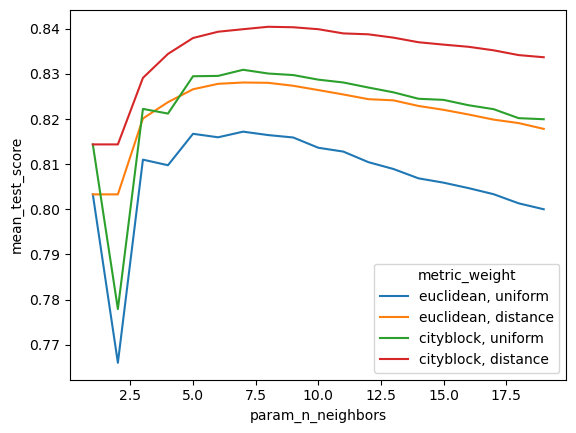

In [44]:
results = pd.DataFrame(grid.cv_results_)
results["metric_weight"] = results["param_metric"] + ", " + results["param_weights"]
sns.lineplot(data=results, x="param_n_neighbors", y="mean_test_score", hue="metric_weight")

### Train

In [45]:
'''
modelC = KNeighborsClassifier(n_neighbors=5,
                              weights='distance', #{‘uniform’, ‘distance’} or callable, default='uniform'
                              algorithm='auto', #{‘auto’, ‘ball_tree’, ‘kd_tree’, ‘brute’}, default=’auto’
                              #leaf_size=30, #default=30, Leaf size passed to BallTree or KDTree.
                              #p=2, #default=2, Power parameter for the Minkowski metric.
                              #metric='minkowski', #default=’minkowski’, with p=2 is equivalent to the standard Euclidean metric.
                              metric_params=None, #dict, default=None, Additional keyword arguments for the metric function.
                              n_jobs=-1 #default=None, The number of parallel jobs to run for neighbors search, -1 means using all processors
                              )

modelC = KNeighborsClassifier(n_neighbors=5, metric="manhattan", weights="distance")
#---------- Fit the model
clf = modelC.fit(X_train_norm, y_train)
'''
#---------- Predict class labels / target values
# Predict on training data
pred_labels_tr = clf.predict(X_train_norm)

# Predict on a test data
pred_labels_te = clf.predict(X_test_norm)


#---------- Print model results
# Basic info about the model
print('---------------------------------------------------------')
print('****************** KNN Classification ******************')    
print('Classes: ', clf.classes_)
print('Effective Metric: ', clf.effective_metric_)
print('Effective Metric Params: ', clf.effective_metric_params_)
print('No. of Samples Fit: ', clf.n_samples_fit_)
#print('Outputs 2D: ', clf.outputs_2d_)
#print('--------------------------------------------------------')
print("")

print('*************** Evaluation on Test Data ***************')
score_te = clf.score(X_test_norm, y_test)
print('Accuracy Score: ', score_te)
# Look at classification report to evaluate the model
print(classification_report(y_test, pred_labels_te))
#print('--------------------------------------------------------')
print("")

print('*************** Evaluation on Training Data ***************')
score_tr = clf.score(X_train_norm, y_train)
print('Accuracy Score: ', score_tr)
# Look at classification report to evaluate the model
print(classification_report(y_train, pred_labels_tr))
print('---------------------------------------------------------')

---------------------------------------------------------
****************** KNN Classification ******************
Classes:  [0 1 2 3 4 5 6 7 8 9]
Effective Metric:  cityblock
Effective Metric Params:  {}
No. of Samples Fit:  16423

*************** Evaluation on Test Data ***************
Accuracy Score:  0.8472070098576122
              precision    recall  f1-score   support

           0       1.00      0.06      0.12        16
           1       0.54      0.43      0.48        49
           2       0.59      0.28      0.38        81
           3       0.79      0.67      0.72        94
           4       0.66      0.53      0.59       250
           5       0.46      0.28      0.35       299
           6       0.88      0.92      0.90       447
           7       0.93      0.93      0.93       766
           8       0.86      0.95      0.90      1599
           9       0.87      0.89      0.88      1877

    accuracy                           0.85      5478
   macro avg       0.76  

- This warning appears because we are calculating precision for a label that has no predicted samples in our dataset, resulting in a division by 0 => maybe we have imbalance labels: Since kNN classification relies on majority voting, having imbalanced data would make it hard for the algorithm to pick anything else than the majority class: Majority classes tend to easily dominate predictions. Minority classes are likely to be misclassified, even when a new instance is closer to them.
- we don't use noise in train_set and model doesn't have those samples => cannot label for some datas (maybe outliers) in test_set

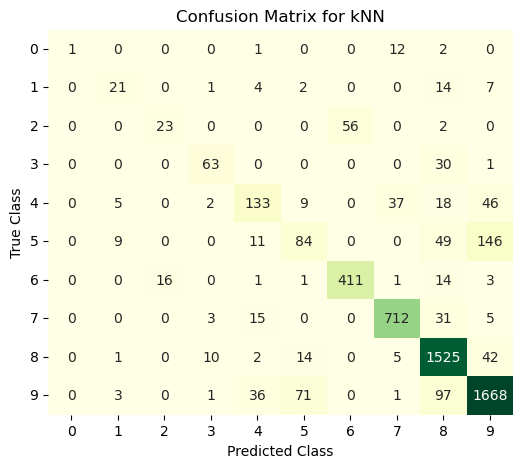

In [46]:
fig, ax = plt.subplots(figsize=(6,5))
cm = confusion_matrix(y_test, pred_labels_te,labels=title)
ax = sns.heatmap(cm, cmap='YlGn', xticklabels=title, yticklabels=title,
                 cbar=False, annot=True, fmt='.0f')
ax.set_title('Confusion Matrix for kNN')
ax.set_xlabel('Predicted Class')
ax.set_ylabel('True Class')
ax.set_yticklabels(title, rotation=0)
plt.show()

In [47]:
cm

array([[   1,    0,    0,    0,    1,    0,    0,   12,    2,    0],
       [   0,   21,    0,    1,    4,    2,    0,    0,   14,    7],
       [   0,    0,   23,    0,    0,    0,   56,    0,    2,    0],
       [   0,    0,    0,   63,    0,    0,    0,    0,   30,    1],
       [   0,    5,    0,    2,  133,    9,    0,   37,   18,   46],
       [   0,    9,    0,    0,   11,   84,    0,    0,   49,  146],
       [   0,    0,   16,    0,    1,    1,  411,    1,   14,    3],
       [   0,    0,    0,    3,   15,    0,    0,  712,   31,    5],
       [   0,    1,    0,   10,    2,   14,    0,    5, 1525,   42],
       [   0,    3,    0,    1,   36,   71,    0,    1,   97, 1668]],
      dtype=int64)

In [48]:
# Total samples per class (sum of each column, representing true labels)
total_per_class = np.sum(cm, axis=1)

# Correct predictions per class (diagonal elements)
correct_per_class = np.diag(cm)

# Misclassified samples per class
misclassified_per_class = total_per_class - correct_per_class

# Misclassification percentage per class
misclassification_percentage_per_class = (misclassified_per_class / total_per_class) * 100

# Create a DataFrame to display results clearly
import pandas as pd

misclassification_df = pd.DataFrame({
    'Class': range(len(total_per_class)),
    'Total Samples': total_per_class,
    'Correct Predictions': correct_per_class,
    'Misclassified Samples': misclassified_per_class,
    'Misclassification Percentage': misclassification_percentage_per_class
})


In [49]:
misclassification_df

,Class,Total Samples,Correct Predictions,Misclassified Samples,Misclassification Percentage
0,0,16,1,15,93.750000
1,1,49,21,28,57.142857
2,2,81,23,58,71.604938
3,3,94,63,31,32.978723
4,4,250,133,117,46.800000
5,5,299,84,215,71.906355
6,6,447,411,36,8.053691
7,7,766,712,54,7.049608
8,8,1599,1525,74,4.627892
9,9,1877,1668,209,11.134790


In [50]:
# Return probability estimates for the test data X.
y_test_pred_proba = clf.predict_proba(X_test_norm)

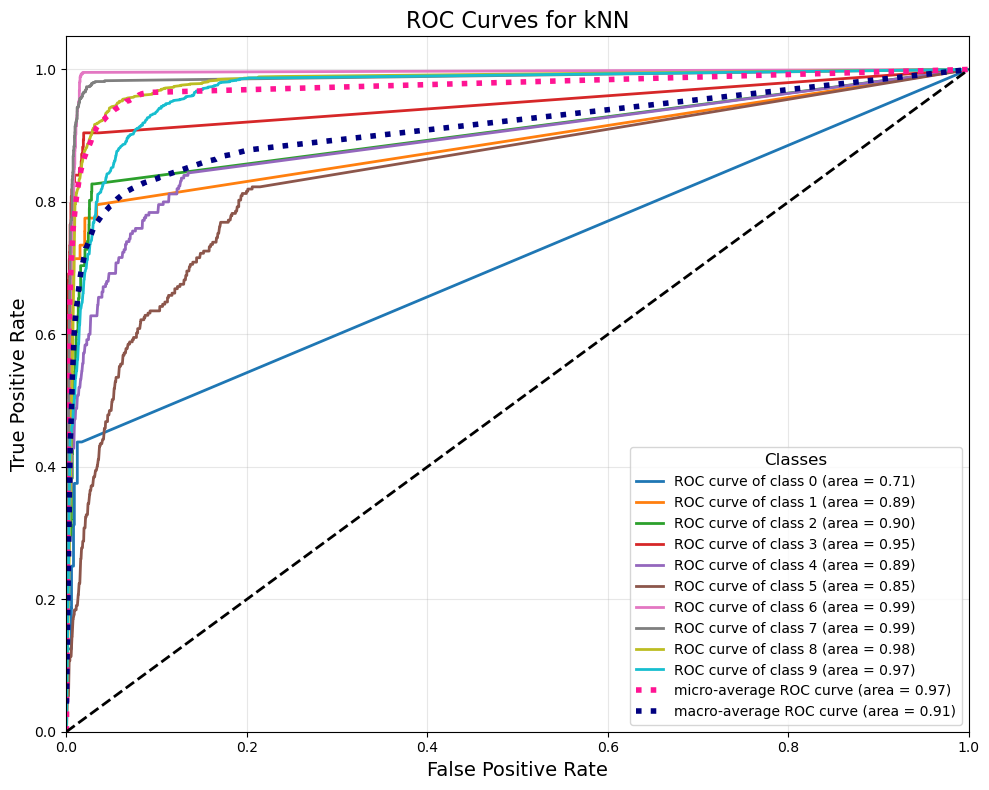

In [51]:
# Plot the ROC curves
plot_roc(y_test, y_test_pred_proba, title='ROC Curves', 
         plot_micro=True, plot_macro=True, classes_to_plot=None,
         figsize=(10, 8), cmap='tab10')

# Customize the plot
plt.title('ROC Curves for kNN', fontsize=16)
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.legend(loc='lower right', fontsize=10, title='Classes', title_fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()

# Show the plot
plt.show()

The closer the ROC curve is to the top left of the graph, the better the model is performing:
- 1 representing perfect classification
- 0.5 representing random classification
- < 0.5 indicating a classifier worse than random guessing

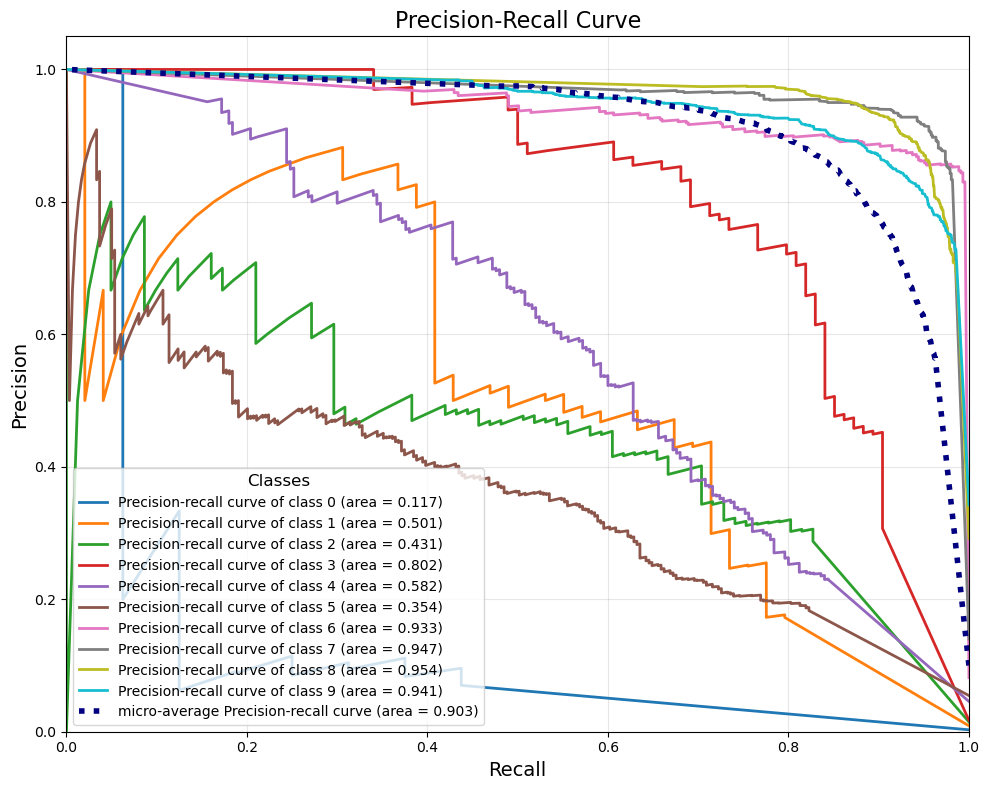

In [52]:
plot_precision_recall(y_test, y_test_pred_proba, title='Precision-Recall Curve',
                      plot_micro=True, classes_to_plot=None, figsize=(10, 8),
                      cmap='tab10')

# Customize the plot
plt.title('Precision-Recall Curve', fontsize=16)
plt.xlabel('Recall', fontsize=14)
plt.ylabel('Precision', fontsize=14)
plt.legend(loc='lower left', fontsize=10, title='Classes', title_fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()

# Show the plot
plt.show()

## Repeat Holdout

In [53]:
N = 50
err = 0

for i in range(N):
    # stratified holdout
    X_rh_train = train.drop(columns=["titleType"])
    y_rh_train = train["titleType"]
    X_rh_test = test.drop(columns=["titleType"])
    y_rh_test = test["titleType"]
    # normalize train set
    norm.fit(X_rh_train)
    X_rh_train_norm = norm.transform(X_rh_train)
    X_rh_test_norm = norm.transform(X_rh_test)

    # initialize and fit classifier
    clf = KNeighborsClassifier(n_neighbors=5, metric="euclidean", weights="uniform")
    clf.fit(X_rh_train_norm, y_rh_train)

    # computing error
    acc = clf.score(X_rh_test_norm, y_rh_test)
    err += 1 - acc

print("Overall error estimate:", err/N)

Overall error estimate: 0.1785323110624315


In [54]:
N = 50
err = 0

for i in range(N):
    # stratified holdout
    X_rh_train = train.drop(columns=["titleType"])
    y_rh_train = train["titleType"]
    X_rh_test = test.drop(columns=["titleType"])
    y_rh_test = test["titleType"]
    # normalize train set
    norm.fit(X_rh_train)
    X_rh_train_norm = norm.transform(X_rh_train)
    X_rh_test_norm = norm.transform(X_rh_test)

    # initialize and fit classifier
    clf = KNeighborsClassifier(n_neighbors=5, metric="manhattan", weights="distance")
    clf.fit(X_rh_train_norm, y_rh_train)

    # computing error
    acc = clf.score(X_rh_test_norm, y_rh_test)
    err += 1 - acc

print("Overall error estimate:", err/N)

Overall error estimate: 0.15425337714494344


## Cross Validation

In [55]:
k=5
clf = KNeighborsClassifier(n_neighbors=5, metric="euclidean", weights="uniform")

scores = cross_val_score(clf, X_train_norm, y_train, cv=k)
scores

array([0.8173516 , 0.82009132, 0.82009132, 0.82399513, 0.81394641])

In [56]:
k=10
clf = KNeighborsClassifier(n_neighbors=5, metric="manhattan", weights="distance")

scores = cross_val_score(clf, X_train_norm, y_train, cv=k)
scores

array([0.83505782, 0.84297018, 0.83870968, 0.84652862, 0.83678441,
       0.84774665, 0.82886724, 0.85140073, 0.83678441, 0.8410475 ])

In [57]:
'''
vectorizer = CountVectorizer()
X_train_vectorized = vectorizer.fit_transform(X_train)
X_test_vectorized = vectorizer.transform(X_test)

# Train a Multinomial Naive Bayes classifier
nb_classifier = MultinomialNB()
nb_classifier.fit(X_train_vectorized, y_train)

# Make predictions on the test set
y_pred = nb_classifier.predict(X_test_vectorized)

# Evaluate the performance of the classifier
accuracy = metrics.accuracy_score(y_test, y_pred)
precision = metrics.precision_score(y_test, y_pred, average='weighted')
recall = metrics.recall_score(y_test, y_pred, average='weighted')
f1_score = metrics.f1_score(y_test, y_pred, average='weighted')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1_score)
'''

'\nvectorizer = CountVectorizer()\nX_train_vectorized = vectorizer.fit_transform(X_train)\nX_test_vectorized = vectorizer.transform(X_test)\n\n# Train a Multinomial Naive Bayes classifier\nnb_classifier = MultinomialNB()\nnb_classifier.fit(X_train_vectorized, y_train)\n\n# Make predictions on the test set\ny_pred = nb_classifier.predict(X_test_vectorized)\n\n# Evaluate the performance of the classifier\naccuracy = metrics.accuracy_score(y_test, y_pred)\nprecision = metrics.precision_score(y_test, y_pred, average=\'weighted\')\nrecall = metrics.recall_score(y_test, y_pred, average=\'weighted\')\nf1_score = metrics.f1_score(y_test, y_pred, average=\'weighted\')\n\nprint("Accuracy:", accuracy)\nprint("Precision:", precision)\nprint("Recall:", recall)\nprint("F1 Score:", f1_score)\n'

# Naive Bayes

### GaussianNB

In [58]:
clf_nb = GaussianNB()

In [59]:
%%time
clf_nb.fit(X_train, y_train)

CPU times: total: 266 ms
Wall time: 35.9 ms


GaussianNB()

In [60]:
y_pred_nb = clf_nb.predict(X_test)

In [61]:
print('*************** Evaluation on Test Data ***************')
score_te = clf_nb.score(X_test, y_test)
print('Accuracy Score: ', score_te)
# Look at classification report to evaluate the model
print(classification_report(y_test, y_pred_nb))

*************** Evaluation on Test Data ***************
Accuracy Score:  0.46276013143483025
              precision    recall  f1-score   support

           0       0.06      0.56      0.12        16
           1       0.03      0.33      0.05        49
           2       0.15      0.16      0.16        81
           3       0.62      0.09      0.15        94
           4       0.41      0.43      0.42       250
           5       0.10      0.32      0.15       299
           6       0.59      0.14      0.23       447
           7       0.66      0.79      0.72       766
           8       0.62      0.80      0.70      1599
           9       0.92      0.18      0.30      1877

    accuracy                           0.46      5478
   macro avg       0.42      0.38      0.30      5478
weighted avg       0.68      0.46      0.46      5478



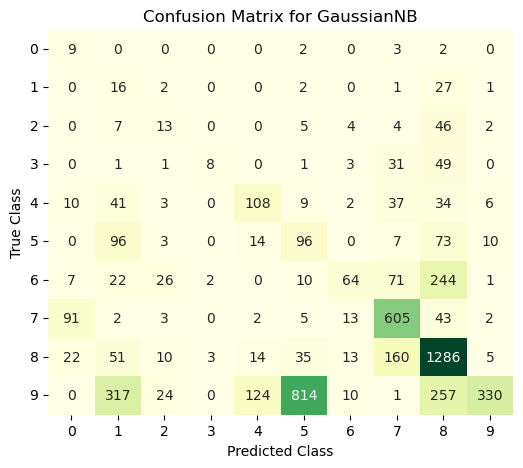

In [62]:
fig, ax = plt.subplots(figsize=(6,5))
cm = confusion_matrix(y_test, y_pred_nb,labels=title)
ax = sns.heatmap(cm, cmap='YlGn', xticklabels=title, yticklabels=title,
                 cbar=False, annot=True, fmt='.0f')
ax.set_title('Confusion Matrix for GaussianNB')
ax.set_xlabel('Predicted Class')
ax.set_ylabel('True Class')
ax.set_yticklabels(title, rotation=0)
plt.show()

In [63]:
y_test_pred_proba_nb = clf_nb.predict_proba(X_test)

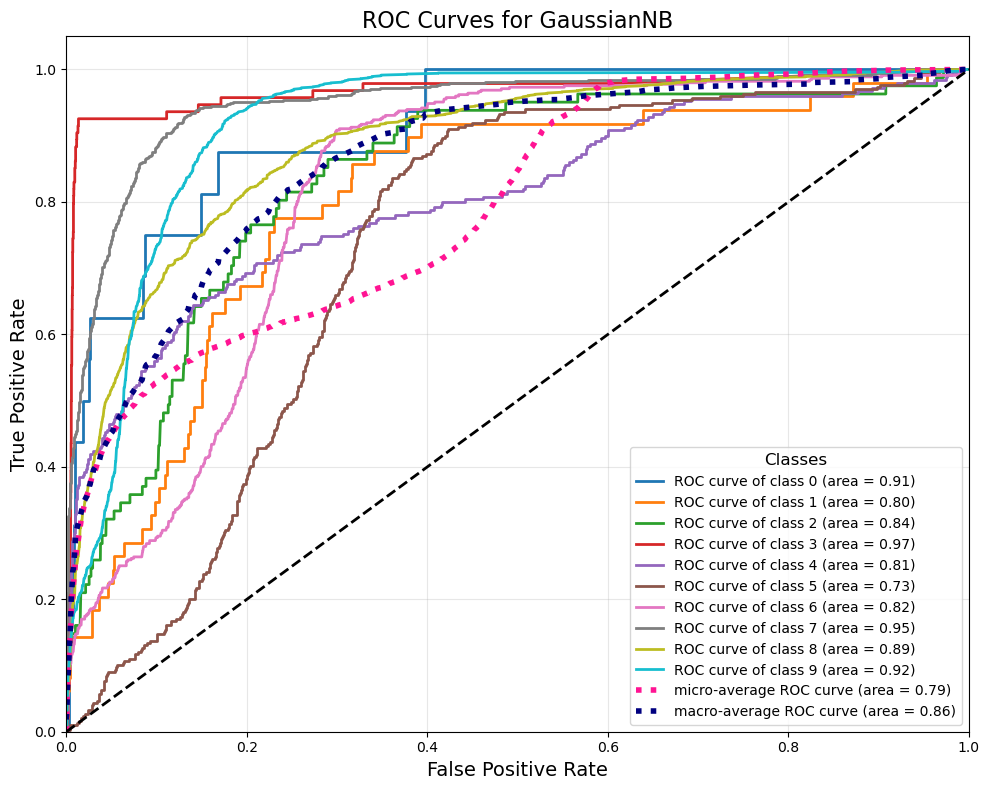

In [64]:
plot_roc(y_test, y_test_pred_proba_nb, title='ROC Curves', 
         plot_micro=True, plot_macro=True, classes_to_plot=None,
         figsize=(10, 8), cmap='tab10')

# Customize the plot
plt.title('ROC Curves for GaussianNB', fontsize=16)
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.legend(loc='lower right', fontsize=10, title='Classes', title_fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()

# Show the plot
plt.show()

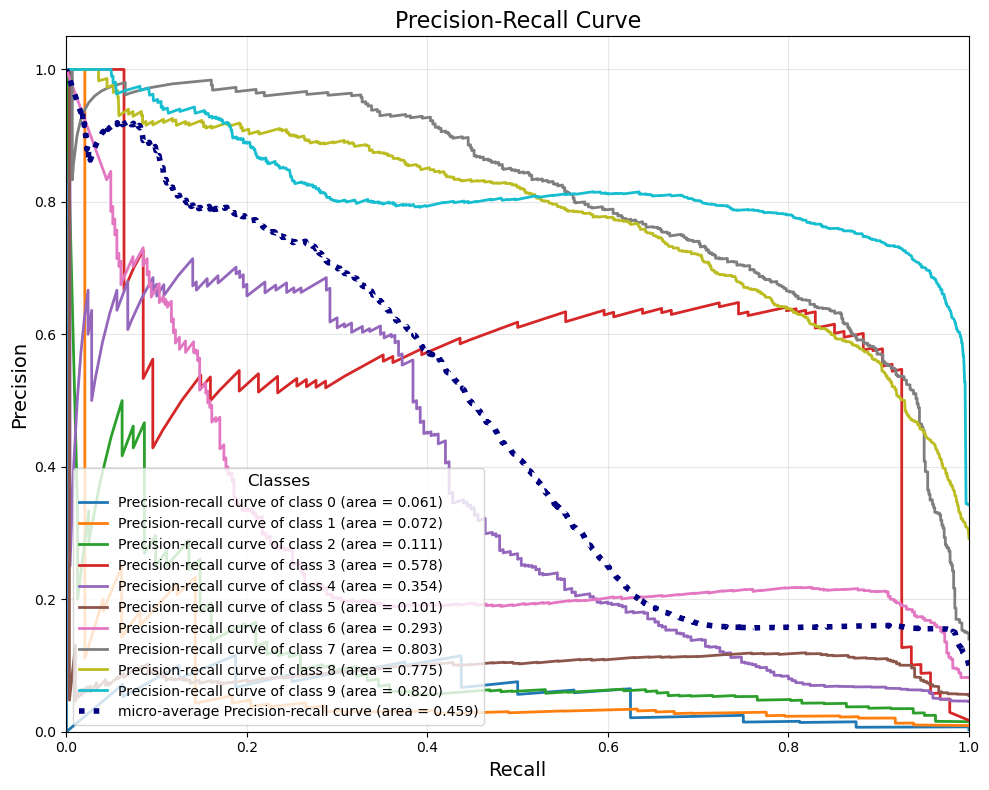

In [65]:
plot_precision_recall(y_test, y_test_pred_proba_nb, title='Precision-Recall Curve',
                      plot_micro=True, classes_to_plot=None, figsize=(10, 8),
                      cmap='tab10')

# Customize the plot
plt.title('Precision-Recall Curve', fontsize=16)
plt.xlabel('Recall', fontsize=14)
plt.ylabel('Precision', fontsize=14)
plt.legend(loc='lower left', fontsize=10, title='Classes', title_fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()

# Show the plot
plt.show()

### CategoricalNB

In [66]:
numeric = ['runtimeMinutes', 'awardWins', 'numVotes', 'totalImages', 
           'totalVideos', 'totalCredits', 'criticReviewsTotal', 'numRegions', 
           'userReviewsTotal','awardNominationsExcludeWins']

bool_vars = ['canHaveEpisodes', 'isAdult']
categorical = ['titleType', 'countryOfOrigin', 'genres']

In [67]:
missing_values(test)

,Nº of missings,% of missings,Above threshold


In [68]:
from sklearn.preprocessing import KBinsDiscretizer

In [69]:
non_cat_columns = numeric

X_train_noncat = X_train[non_cat_columns].values
X_test_noncat = X_test[non_cat_columns].values

discretizer = KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='uniform')
X_train_cat = discretizer.fit_transform(X_train_noncat)
X_test_cat = discretizer.transform(X_test_noncat)

print(X_train_cat.shape, X_test_cat.shape)

(16423, 10) (5478, 10)


In [70]:
clf_cnb = CategoricalNB()
clf_cnb.fit(X_train_cat, y_train)

CategoricalNB()

In [71]:
y_pred_cnb = clf_cnb.predict(X_test_cat)

In [72]:
print(classification_report(y_test, y_pred_cnb))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        16
           1       0.00      0.00      0.00        49
           2       0.33      0.05      0.09        81
           3       0.00      0.00      0.00        94
           4       0.00      0.00      0.00       250
           5       0.00      0.00      0.00       299
           6       0.91      0.02      0.04       447
           7       0.00      0.00      0.00       766
           8       0.00      0.00      0.00      1599
           9       0.34      1.00      0.51      1877

    accuracy                           0.34      5478
   macro avg       0.16      0.11      0.06      5478
weighted avg       0.20      0.34      0.18      5478



c:\Users\hiend\miniconda3\envs\corso\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\hiend\miniconda3\envs\corso\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\hiend\miniconda3\envs\corso\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Decision Tree

### Overfitting vs Underfitting?

In [73]:
nodes = []
train_err = []
test_err = []

for max_depth in list(np.arange(1, 20)):
    dt = DecisionTreeClassifier(max_depth=max_depth)
    dt.fit(X_train, y_train)
    y_train_pred = dt.predict(X_train)
    y_test_pred = dt.predict(X_test)

    train_err.append(1 - accuracy_score(y_train, y_train_pred))
    test_err.append(1 - accuracy_score(y_test, y_test_pred))
    nodes.append(dt.tree_.node_count)

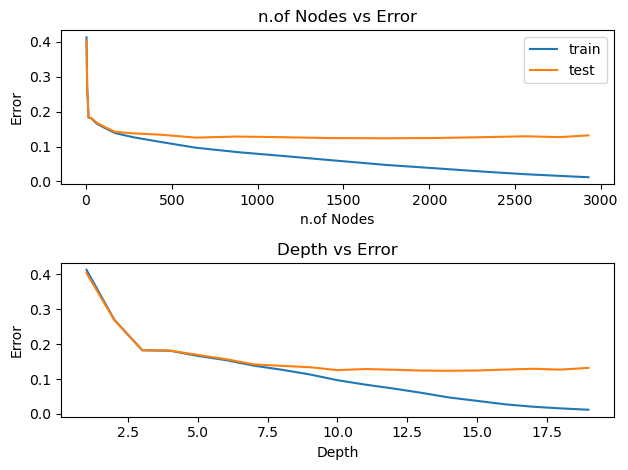

In [74]:
fig, ax = plt.subplots(2,1)
ax[0].plot(nodes, train_err, label='train')
ax[0].plot(nodes, test_err, label='test')
ax[0].legend()

ax[0].set_xlabel("n.of Nodes")
ax[0].set_ylabel("Error")
ax[0].set_title("n.of Nodes vs Error")

ax[1].plot(list(np.arange(1, 20)), train_err, label='train')
ax[1].plot(list(np.arange(1, 20)), test_err, label='test')

ax[1].set_xlabel("Depth")
ax[1].set_ylabel("Error")
ax[1].set_title("Depth vs Error")

plt.tight_layout()
plt.show()

- Depth: 7-10 (balance between avoiding underfitting and overfitting)
- Smaller depth and number of nodes lead to underfitting (high error on both training and test sets). Conversely, too large depth or number of nodes causes overfitting (test error increases while training error continues to decrease).

### parameter

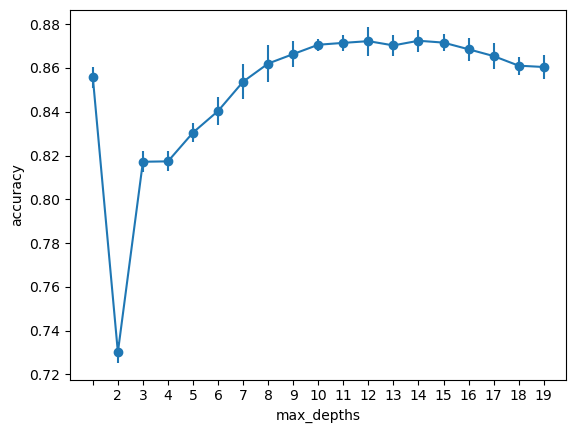

In [75]:
max_depths = [None] + list(np.arange(2, 20))
avg_scores = list()
std_scores = list()

for max_depth in max_depths:
    dt = DecisionTreeClassifier(max_depth=max_depth)
    scores = cross_val_score(dt, X_train, y_train, cv=5)
    avg_scores.append(np.mean(scores))
    std_scores.append(np.std(scores))

plt.errorbar(range(len(max_depths)), y=avg_scores, yerr=std_scores, marker='o')
plt.xticks(range(len(max_depths)), max_depths)
plt.xlabel("max_depths")
plt.ylabel("accuracy")
plt.show()

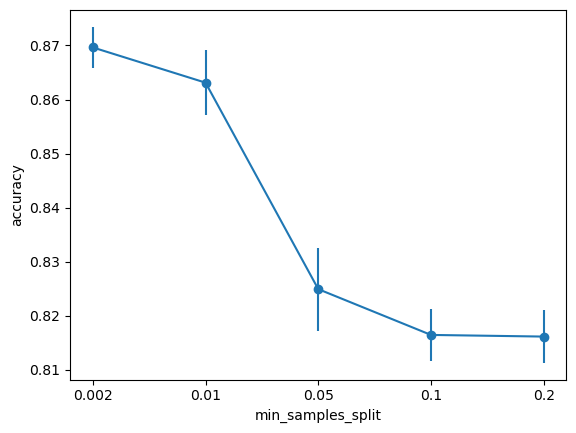

In [76]:
min_samples_splits = [0.002, 0.01, 0.05, 0.1, 0.2]
avg_scores = list()
std_scores = list()

for min_samples_split in min_samples_splits:
    dt = DecisionTreeClassifier(min_samples_split=min_samples_split)
    scores = cross_val_score(dt, X_train, y_train, cv=5)
    avg_scores.append(np.mean(scores))
    std_scores.append(np.std(scores))

plt.errorbar(range(len(min_samples_splits)), y=avg_scores, yerr=std_scores, marker='o')
plt.xticks(range(len(min_samples_splits)), min_samples_splits)
plt.xlabel("min_samples_split")
plt.ylabel("accuracy")
plt.show()

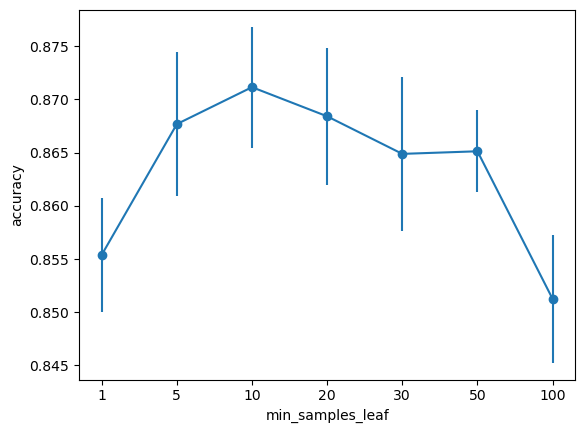

In [77]:
min_samples_leafs = [1, 5, 10, 20, 30, 50, 100]
avg_scores = list()
std_scores = list()

for min_samples_leaf in min_samples_leafs:
    dt = DecisionTreeClassifier(min_samples_leaf=min_samples_leaf)
    scores = cross_val_score(dt, X_train, y_train, cv=5)
    avg_scores.append(np.mean(scores))
    std_scores.append(np.std(scores))

plt.errorbar(range(len(min_samples_leafs)), y=avg_scores, yerr=std_scores, marker='o')
plt.xticks(range(len(min_samples_leafs)), min_samples_leafs)
plt.xlabel("min_samples_leaf")
plt.ylabel("accuracy")
plt.show()

### Hyperparameters

In [78]:
from sklearn.tree._tree import TREE_LEAF
def is_leaf(inner_tree, index):
    # Check whether node is leaf node
    return (inner_tree.children_left[index] == TREE_LEAF and
            inner_tree.children_right[index] == TREE_LEAF)


def prune_index(inner_tree, decisions, index=0):
    # Start pruning from the bottom - if we start from the top, we might miss
    # nodes that become leaves during pruning.
    # Do not use this directly - use prune_duplicate_leaves instead.
    if not is_leaf(inner_tree, inner_tree.children_left[index]):
        prune_index(inner_tree, decisions, inner_tree.children_left[index])
    if not is_leaf(inner_tree, inner_tree.children_right[index]):
        prune_index(inner_tree, decisions, inner_tree.children_right[index])

    # Prune children if both children are leaves now and make the same decision:
    if (is_leaf(inner_tree, inner_tree.children_left[index]) and
        is_leaf(inner_tree, inner_tree.children_right[index]) and
        (decisions[index] == decisions[inner_tree.children_left[index]]) and
        (decisions[index] == decisions[inner_tree.children_right[index]])):
        # turn node into a leaf by "unlinking" its children
        inner_tree.children_left[index] = TREE_LEAF
        inner_tree.children_right[index] = TREE_LEAF
        # print("Pruned {}".format(index))


def prune_duplicate_leaves(dt):
    # Remove leaves if both
    decisions = dt.tree_.value.argmax(axis=2).flatten().tolist()  # Decision for each node
    prune_index(dt.tree_, decisions)

In [79]:
param_list = {
    'max_depth': [None] + list(np.arange(2, 20)),
    'min_samples_split': [2, 5, 10, 20, 30],
    'min_samples_leaf': [1, 5, 10, 20, 30],
    'criterion': ['gini', 'entropy']
}

random_search = RandomizedSearchCV(
    DecisionTreeClassifier(),
    param_distributions=param_list,
    cv=RepeatedStratifiedKFold(random_state=0),
    n_jobs=-1,
    refit=True,
    n_iter=200,
    #verbose=2
)

random_search.fit(X_train, y_train)
dt = random_search.best_estimator_

In [80]:
import pickle

with open('decision_tree_model.pkl', 'wb') as file:
    pickle.dump(dt, file)

In [81]:
with open('decision_tree_model.pkl', 'rb') as file:
    dt = pickle.load(file)

In [82]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 30, 'min_samples_leaf': 5, 'max_depth': 12, 'criterion': 'entropy'} 0.8760031590831985


In [83]:
y_test_pred_dt = dt.predict(X_test)
print(classification_report(y_test, y_test_pred_dt))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        16
           1       0.38      0.35      0.36        49
           2       0.69      0.53      0.60        81
           3       0.98      0.93      0.95        94
           4       0.73      0.50      0.59       250
           5       0.60      0.37      0.46       299
           6       0.92      0.96      0.94       447
           7       0.91      0.96      0.93       766
           8       0.93      0.94      0.94      1599
           9       0.86      0.94      0.90      1877

    accuracy                           0.88      5478
   macro avg       0.70      0.65      0.67      5478
weighted avg       0.87      0.88      0.87      5478



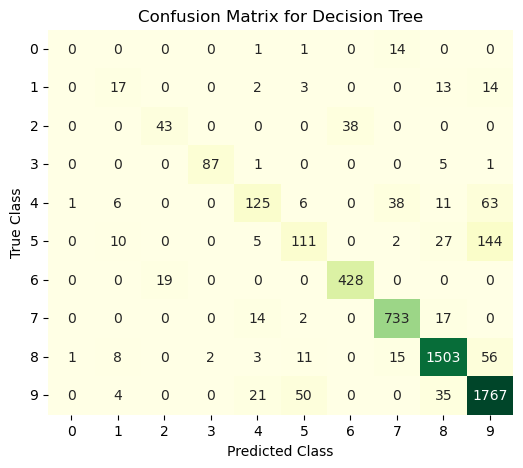

In [84]:
fig, ax = plt.subplots(figsize=(6,5))
cm = confusion_matrix(y_test, y_test_pred_dt,labels=title)
ax = sns.heatmap(cm, cmap='YlGn', xticklabels=title, yticklabels=title,
                 cbar=False, annot=True, fmt='.0f')
ax.set_title('Confusion Matrix for Decision Tree')
ax.set_xlabel('Predicted Class')
ax.set_ylabel('True Class')
ax.set_yticklabels(title, rotation=0)
plt.show()

In [85]:
y_test_pred_proba_dt = dt.predict_proba(X_test)

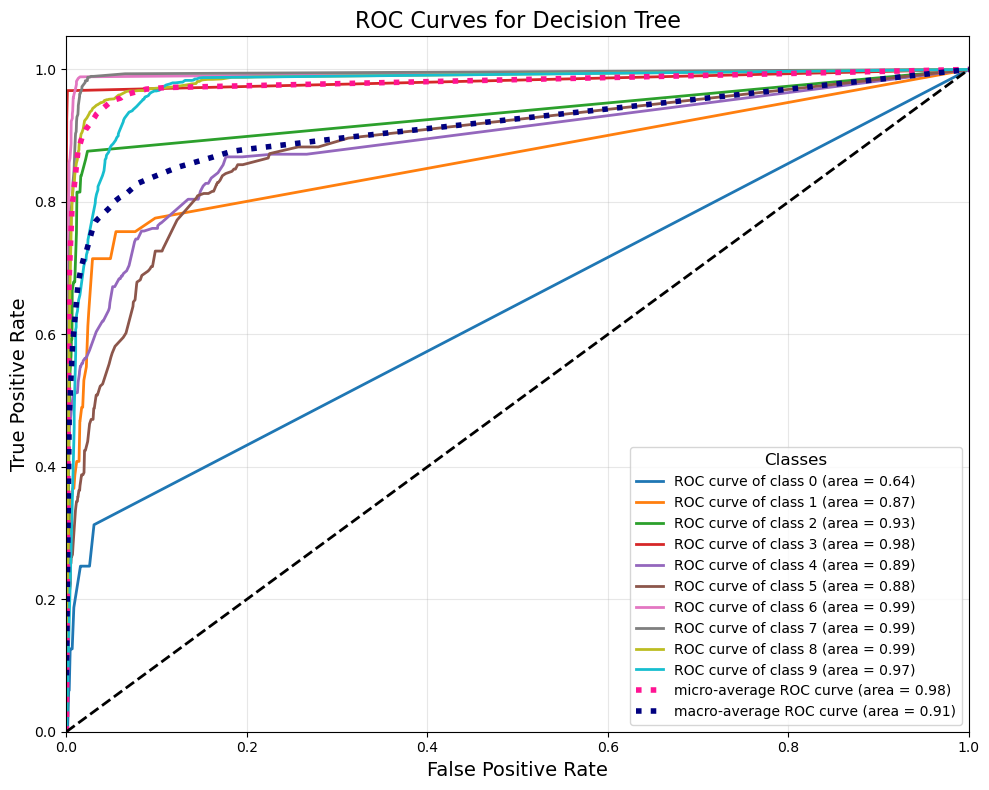

In [86]:
plot_roc(y_test, y_test_pred_proba_dt, title='ROC Curves', 
         plot_micro=True, plot_macro=True, classes_to_plot=None,
         figsize=(10, 8), cmap='tab10')

# Customize the plot
plt.title('ROC Curves for Decision Tree', fontsize=16)
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.legend(loc='lower right', fontsize=10, title='Classes', title_fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()

# Show the plot
plt.show()

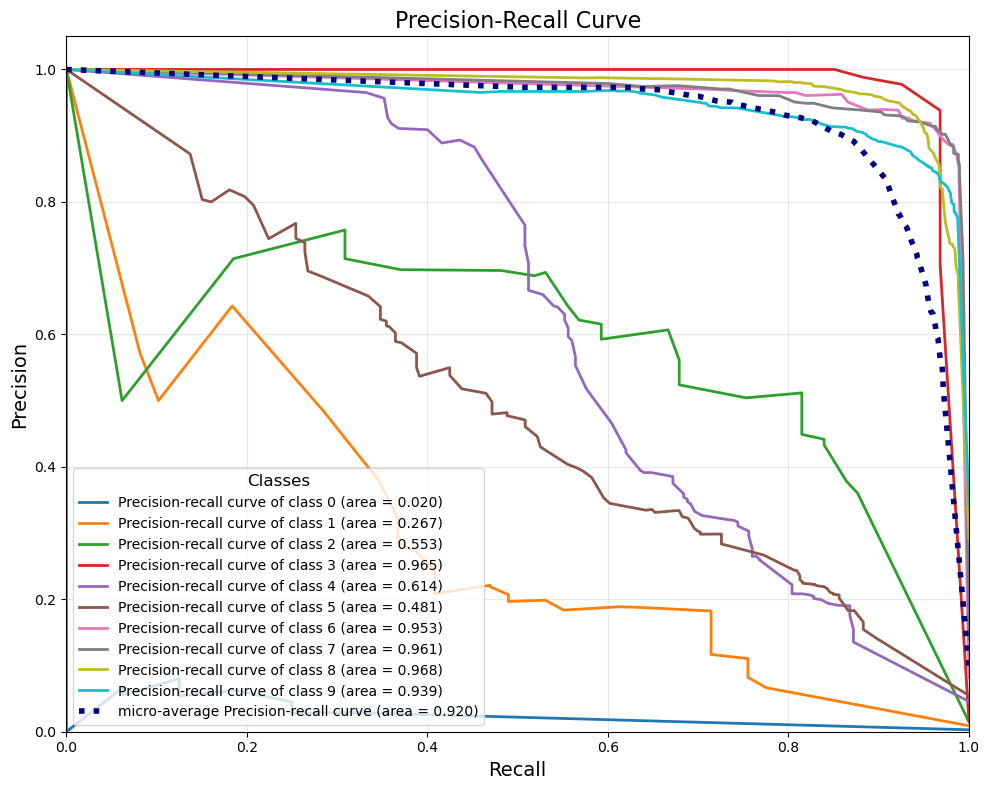

In [87]:
plot_precision_recall(y_test, y_test_pred_proba_dt, title='Precision-Recall Curve',
                      plot_micro=True, classes_to_plot=None, figsize=(10, 8),
                      cmap='tab10')

# Customize the plot
plt.title('Precision-Recall Curve', fontsize=16)
plt.xlabel('Recall', fontsize=14)
plt.ylabel('Precision', fontsize=14)
plt.legend(loc='lower left', fontsize=10, title='Classes', title_fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()

# Show the plot
plt.show()

In [88]:
attributes = X_train.columns.tolist()
target_names = ["tvShort","tvSpecial","tvMiniSeries","videoGame","video","tvMovie","tvSeries","short","tvEpisode", "movie"]

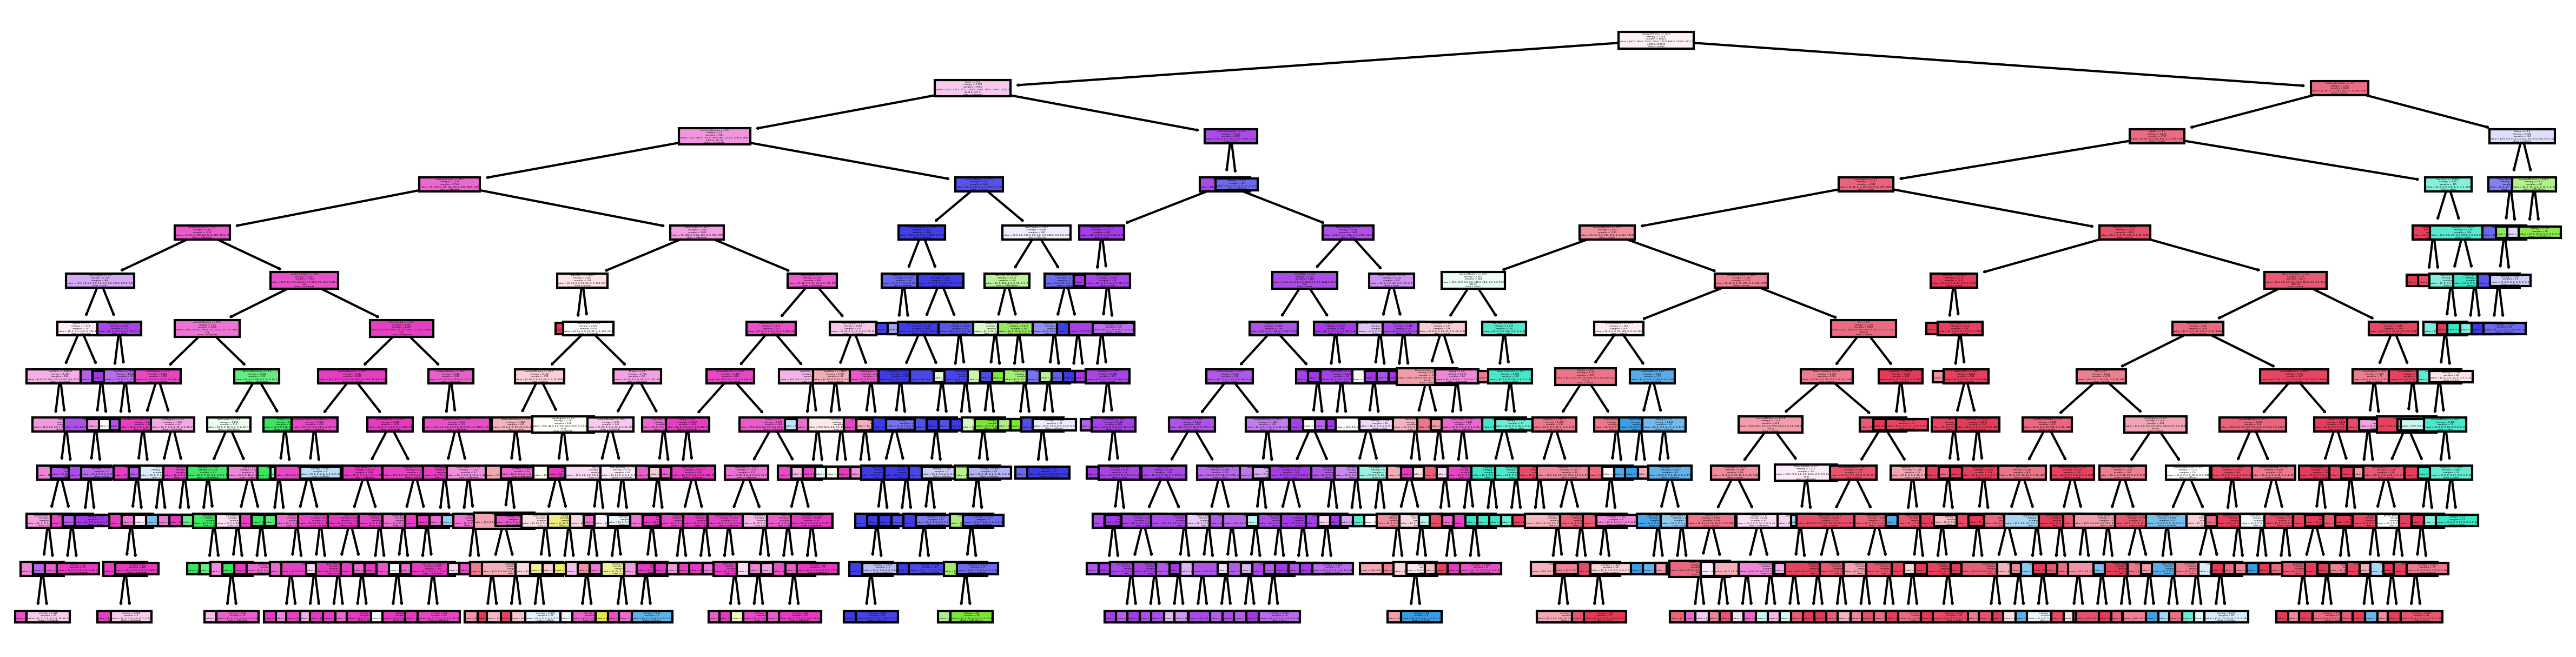

In [89]:
plt.figure(figsize=(20, 5), dpi=300)
plot_tree(dt, feature_names=attributes,class_names=target_names,filled=True)
plt.show()

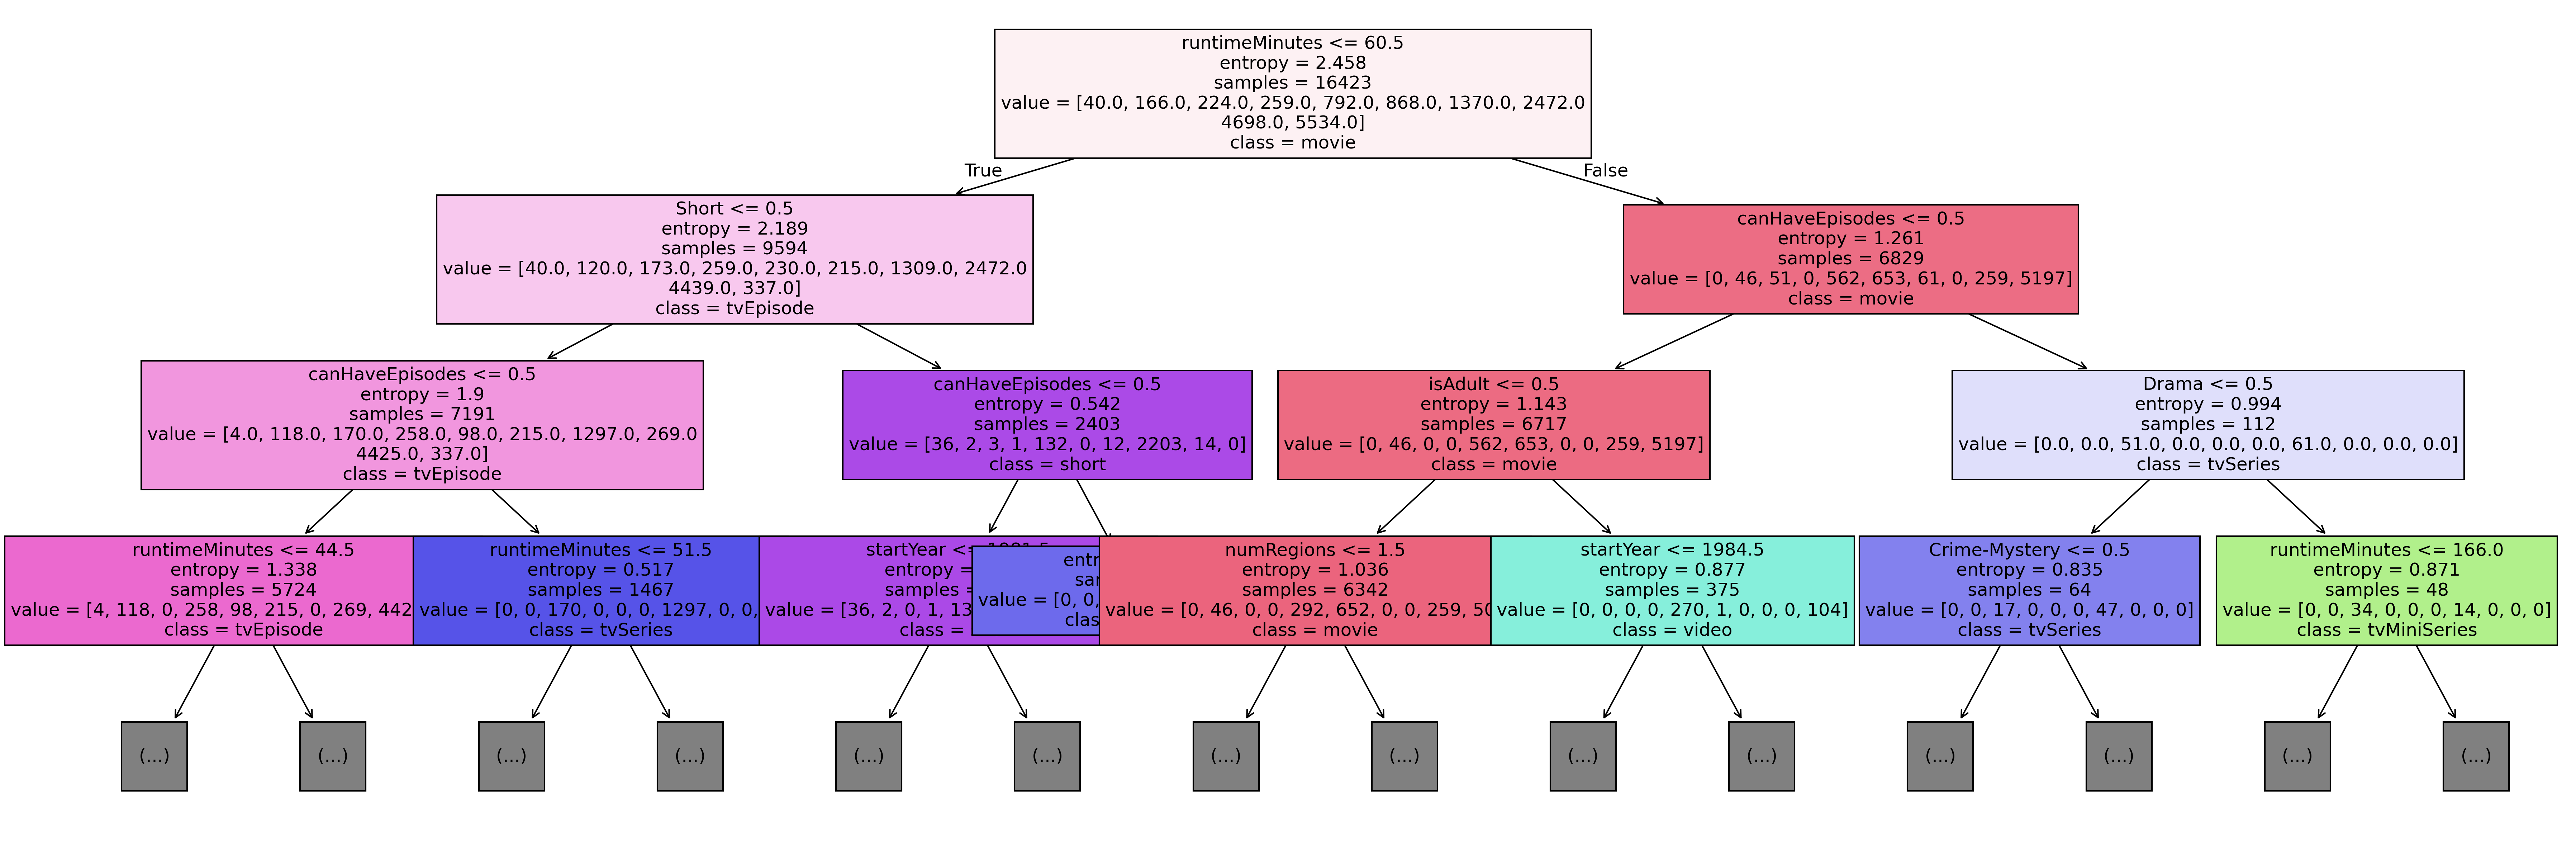

In [90]:
plt.figure(figsize=(30, 10), dpi=300)
plot_tree(dt, feature_names=attributes,class_names=target_names,max_depth=3,filled=True, fontsize=12)
plt.show()

### ccp_alphas

In [91]:
path = dt.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

Text(0.5, 1.0, 'Total Impurity vs effective alpha for training set')

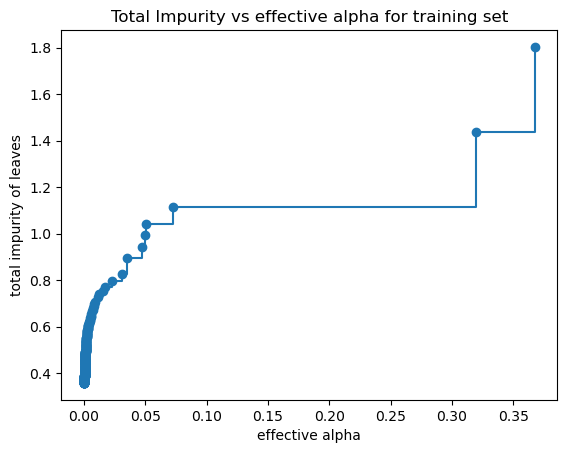

In [92]:
fig, ax = plt.subplots()
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves")
ax.set_title("Total Impurity vs effective alpha for training set")

In [93]:
dts = []
for ccp_alpha in ccp_alphas:
    clfdt = DecisionTreeClassifier(random_state=0, ccp_alpha=ccp_alpha, **random_search.best_params_)
    clfdt.fit(X_train, y_train)
    dts.append(clfdt)
    
print("Number of nodes in the last tree is: {} with ccp_alpha: {}".format(
        dts[-1].tree_.node_count, ccp_alphas[-1]
))

Number of nodes in the last tree is: 1 with ccp_alpha: 0.6541937477250577


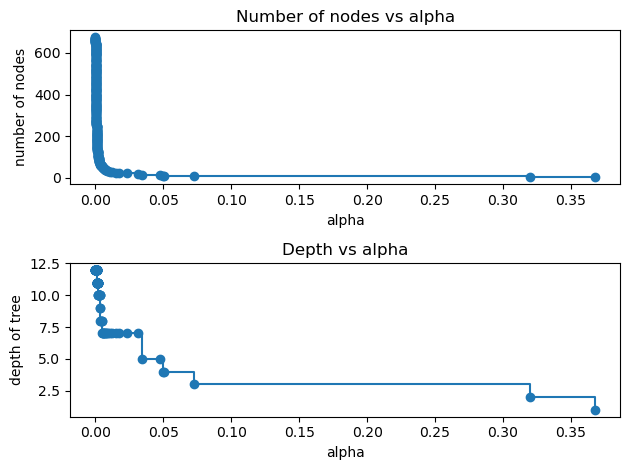

In [94]:
dts = dts[:-1]
ccp_alphas = ccp_alphas[:-1]

node_counts = [clfdt.tree_.node_count for clfdt in dts]
depth = [clfdt.tree_.max_depth for clfdt in dts]

fig, ax = plt.subplots(2, 1)
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")
ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")
fig.tight_layout()

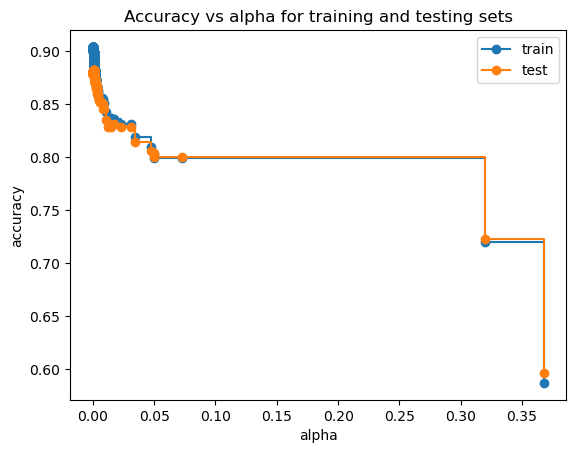

In [95]:
train_scores = [clfdt.score(X_train, y_train) for clfdt in dts]
test_scores = [clfdt.score(X_test, y_test) for clfdt in dts]

fig, ax = plt.subplots()
ax.set_xlabel("alpha")
ax.set_ylabel("accuracy")
ax.set_title("Accuracy vs alpha for training and testing sets")
ax.plot(ccp_alphas, train_scores, marker="o", label="train", drawstyle="steps-post")
ax.plot(ccp_alphas, test_scores, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

In [96]:
dt_prune = DecisionTreeClassifier(ccp_alpha=0.02, **random_search.best_params_)
dt_prune=dt_prune.fit(X_train, y_train)

In [97]:
y_test_pred_dt_prune = dt_prune.predict(X_test)
print(classification_report(y_test, y_test_pred_dt_prune))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        16
           1       0.00      0.00      0.00        49
           2       0.00      0.00      0.00        81
           3       0.87      0.98      0.92        94
           4       0.68      0.34      0.45       250
           5       0.00      0.00      0.00       299
           6       0.85      0.99      0.91       447
           7       0.87      0.98      0.92       766
           8       0.93      0.86      0.89      1599
           9       0.76      0.96      0.85      1877

    accuracy                           0.83      5478
   macro avg       0.49      0.51      0.49      5478
weighted avg       0.77      0.83      0.79      5478



c:\Users\hiend\miniconda3\envs\corso\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\hiend\miniconda3\envs\corso\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\hiend\miniconda3\envs\corso\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


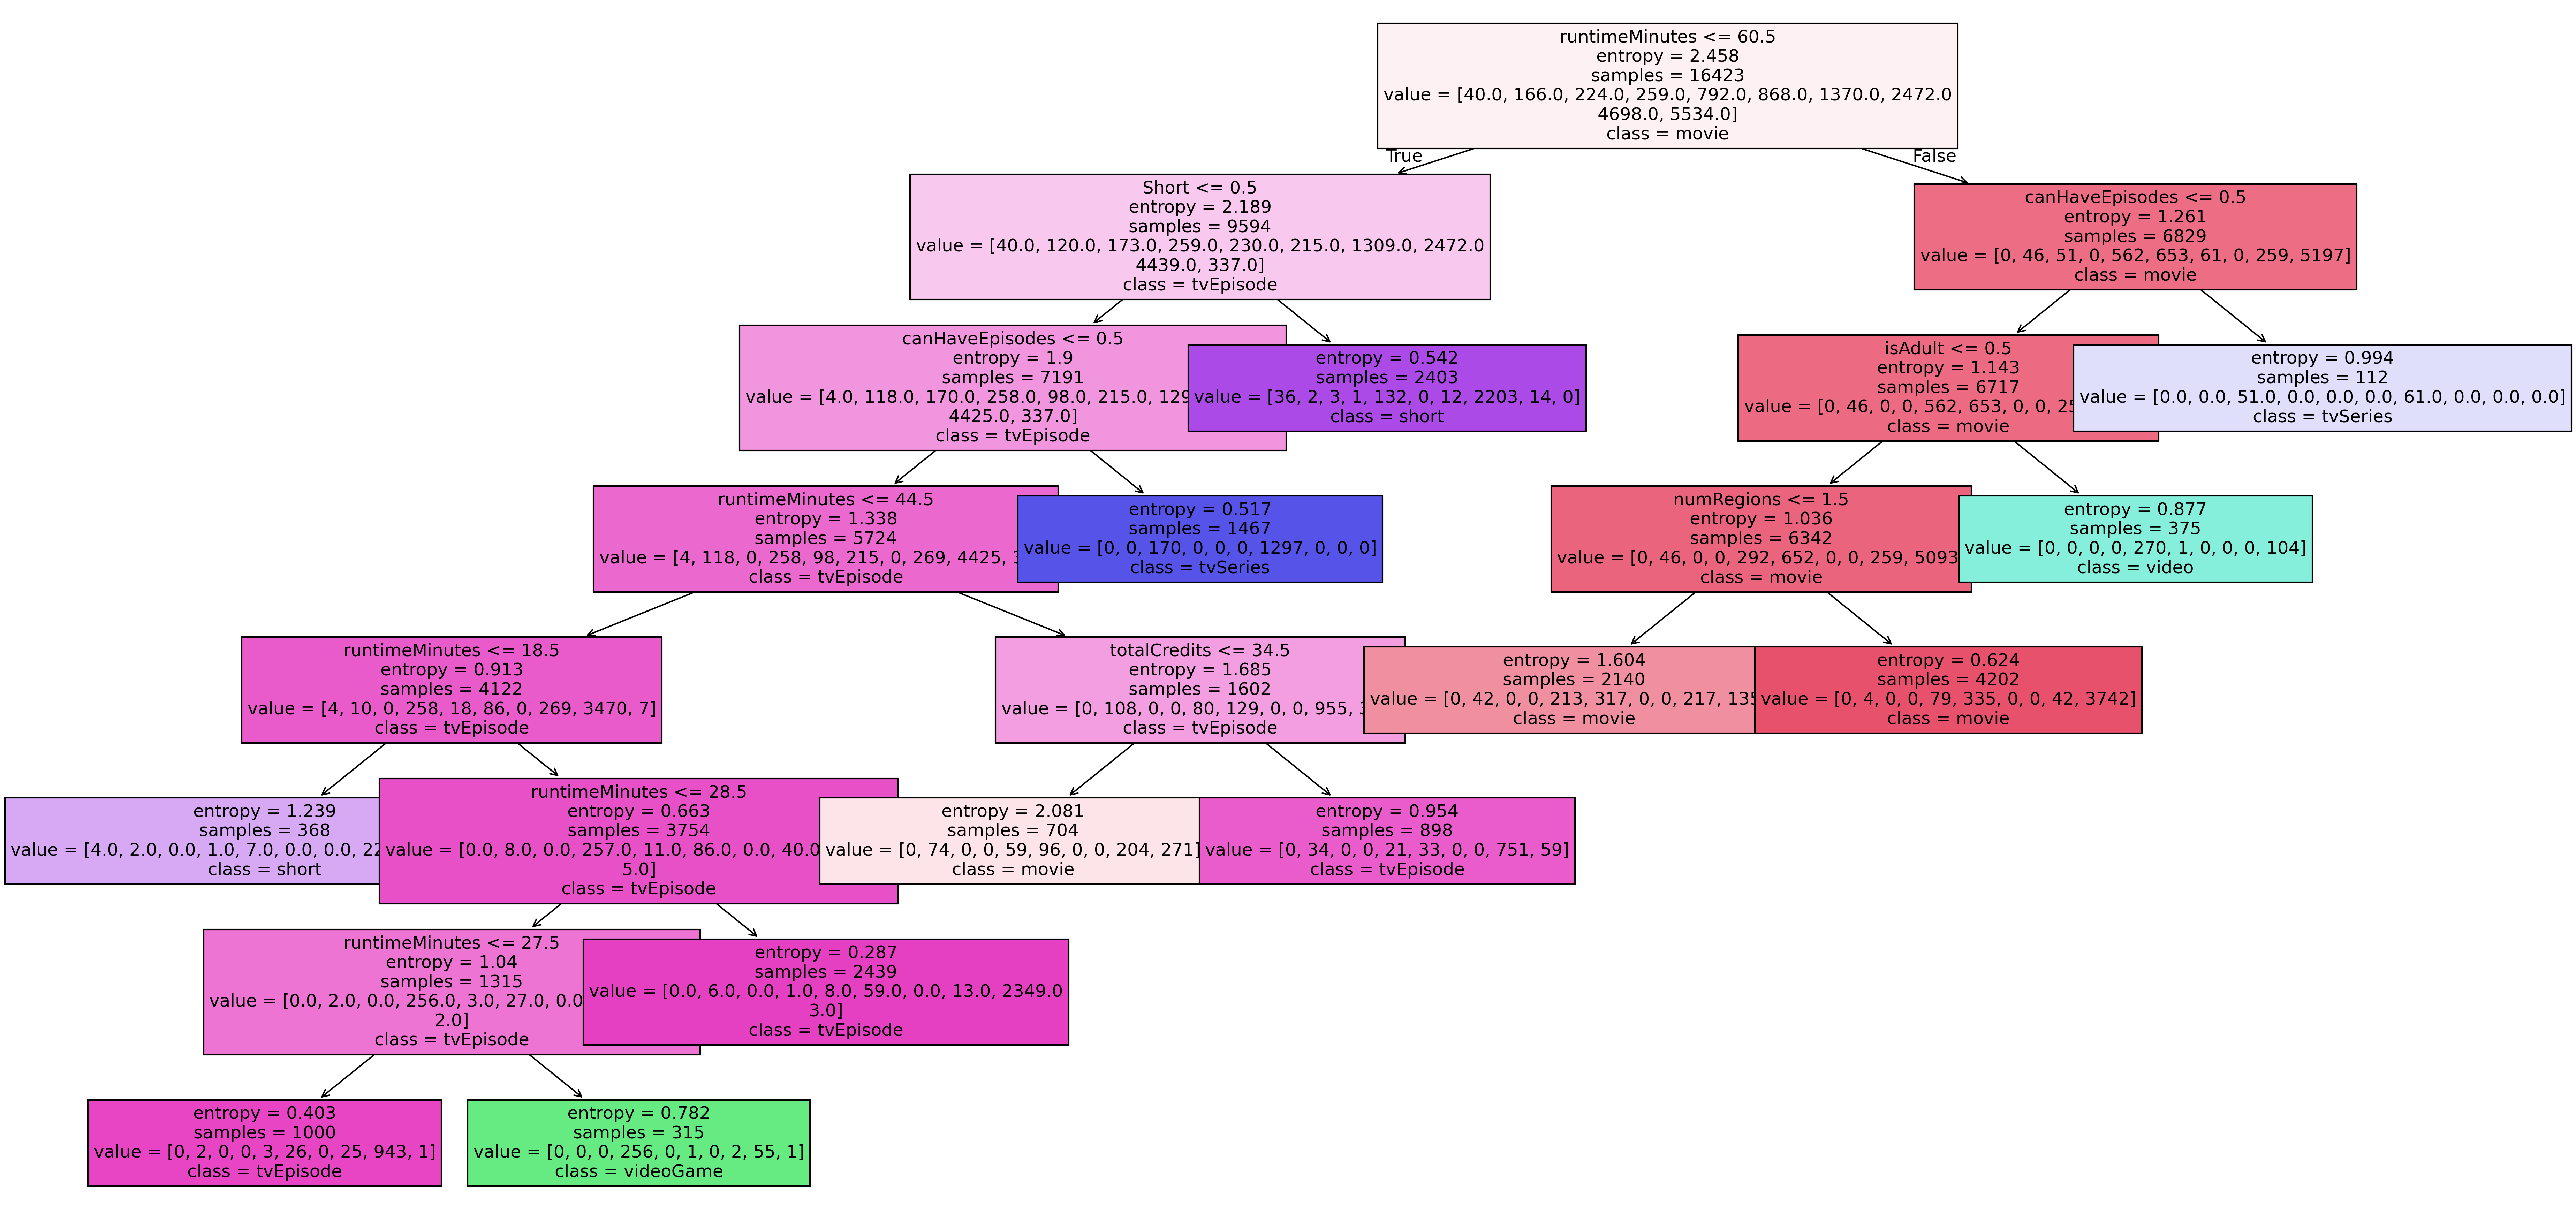

In [98]:
plt.figure(figsize=(30, 15), dpi=300)
plot_tree(dt_prune, feature_names=attributes,class_names=target_names,filled=True,fontsize=12)
plt.show()

### Prune

In [99]:
prune_duplicate_leaves(dt_prune)

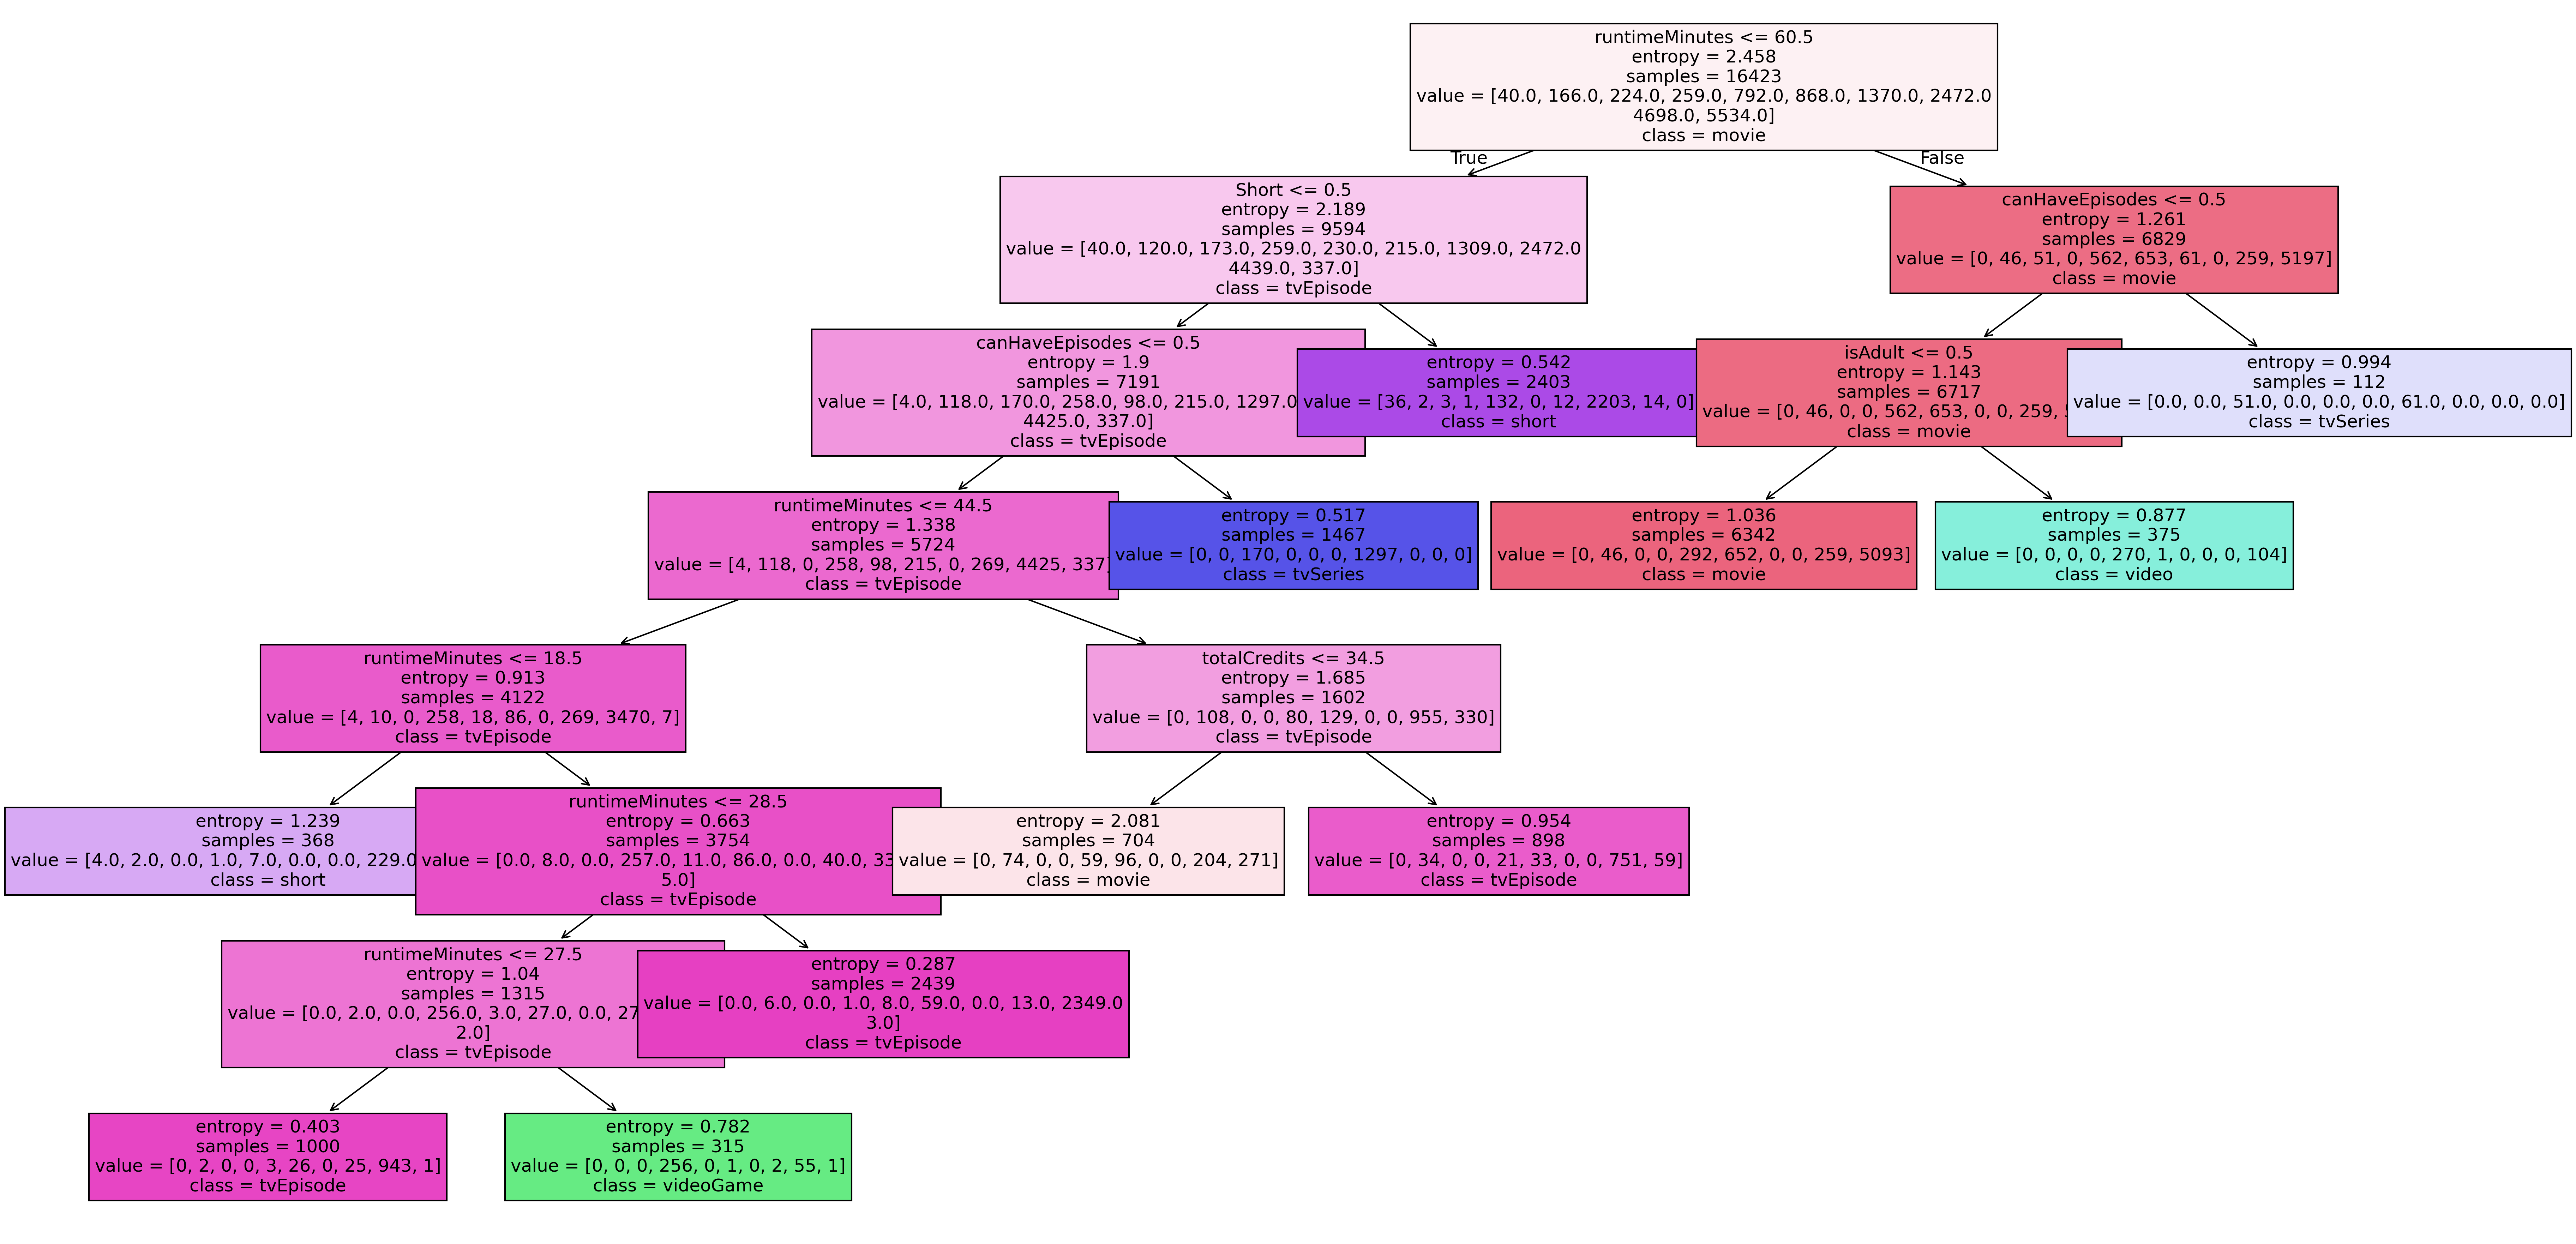

In [100]:
plt.figure(figsize=(30, 15), dpi=300)
plot_tree(dt_prune,feature_names=attributes, class_names=target_names,filled=True, fontsize=12)
plt.show()